In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



In [101]:
cancer = pd.read_csv('../../Data/cancer.csv')
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [102]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [103]:
cancer.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [104]:
cancer.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

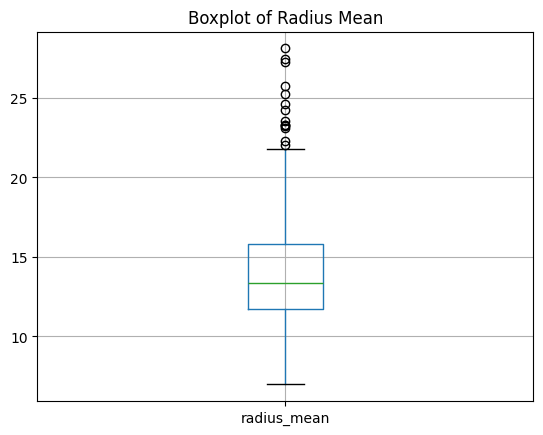

In [105]:
cancer.boxplot(column=['radius_mean'])
plt.title('Boxplot of Radius Mean')
plt.show()

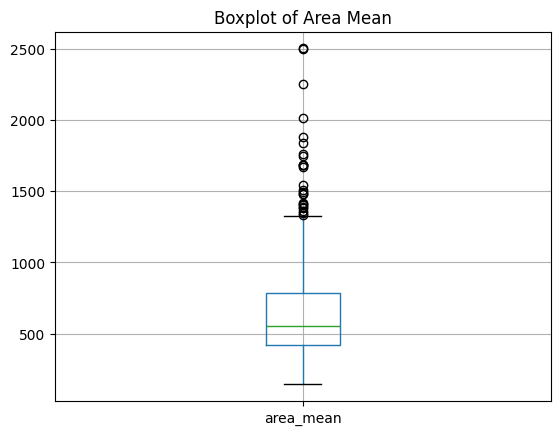

In [106]:
cancer.boxplot(column=['area_mean'])
plt.title('Boxplot of Area Mean')
plt.show()

In [107]:
# Cek dan isi missing values jika ada
if cancer.isnull().sum().sum() > 0:
    for col in cancer.select_dtypes(include=[np.number]).columns:
        if cancer[col].isnull().sum() > 0:
            cancer[col].fillna(cancer[col].median(), inplace=True)

In [108]:
cancer.describe(exclude='object')

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [109]:
cancer['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

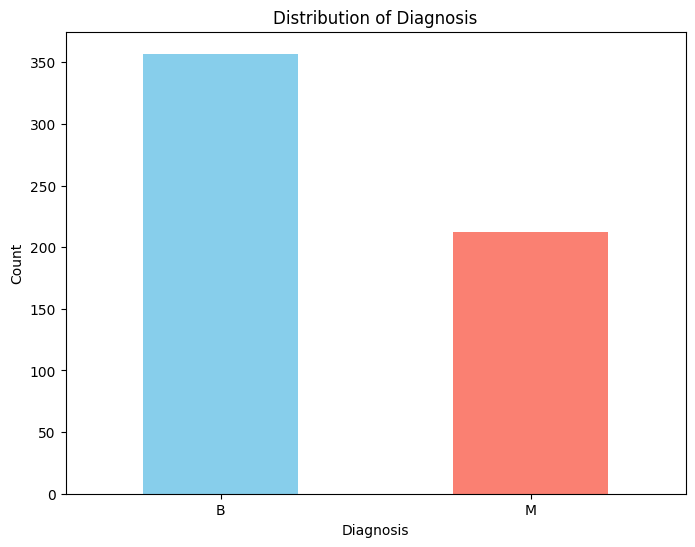

In [110]:
# Distribusi diagnosis

plt.figure(figsize=(8, 6))

cancer['diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks(rotation=0)

plt.title('Distribution of Diagnosis')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.show()

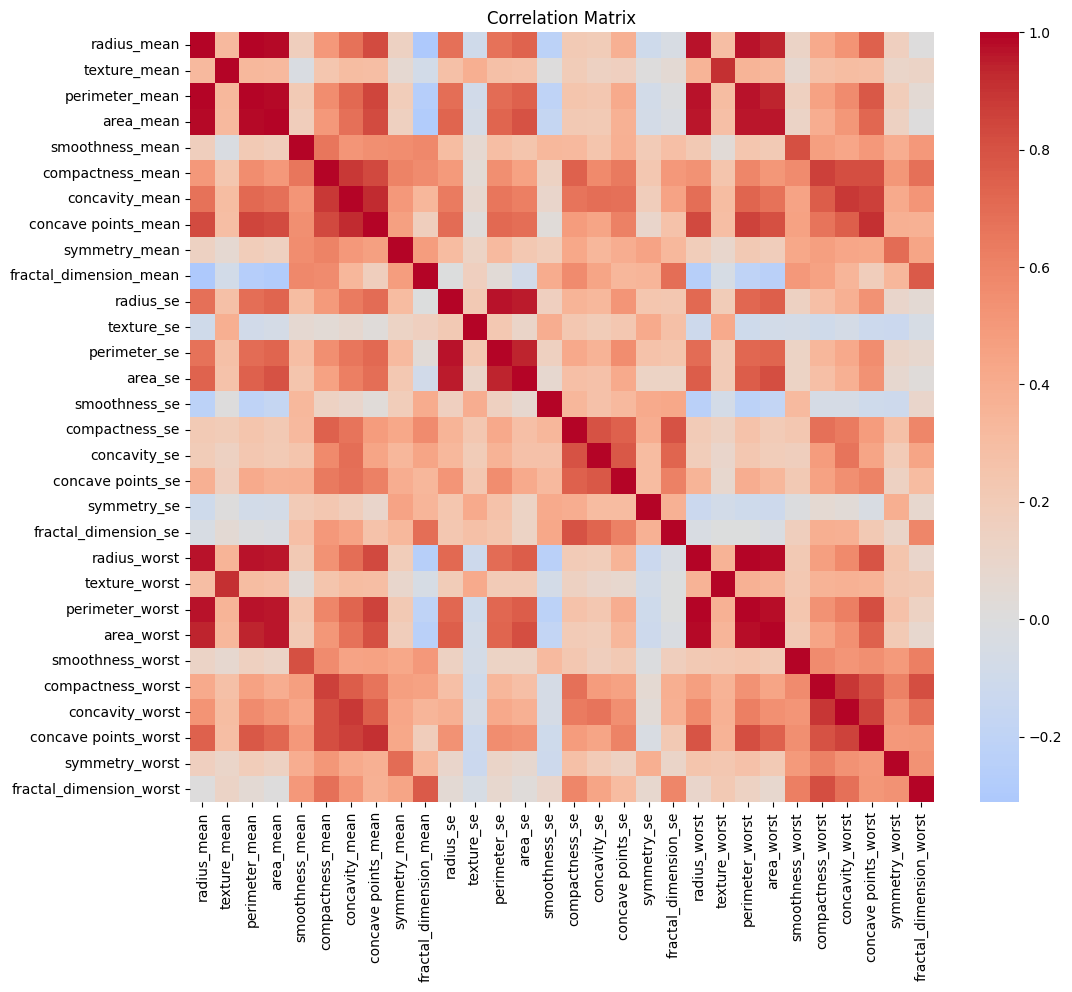

In [111]:
# Korelasi fitur dengan diagnosis

plt.figure(figsize=(12, 10))

corr_matrix = cancer.corr(numeric_only=True)
plt.tight_layout()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_106092\2481492721.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


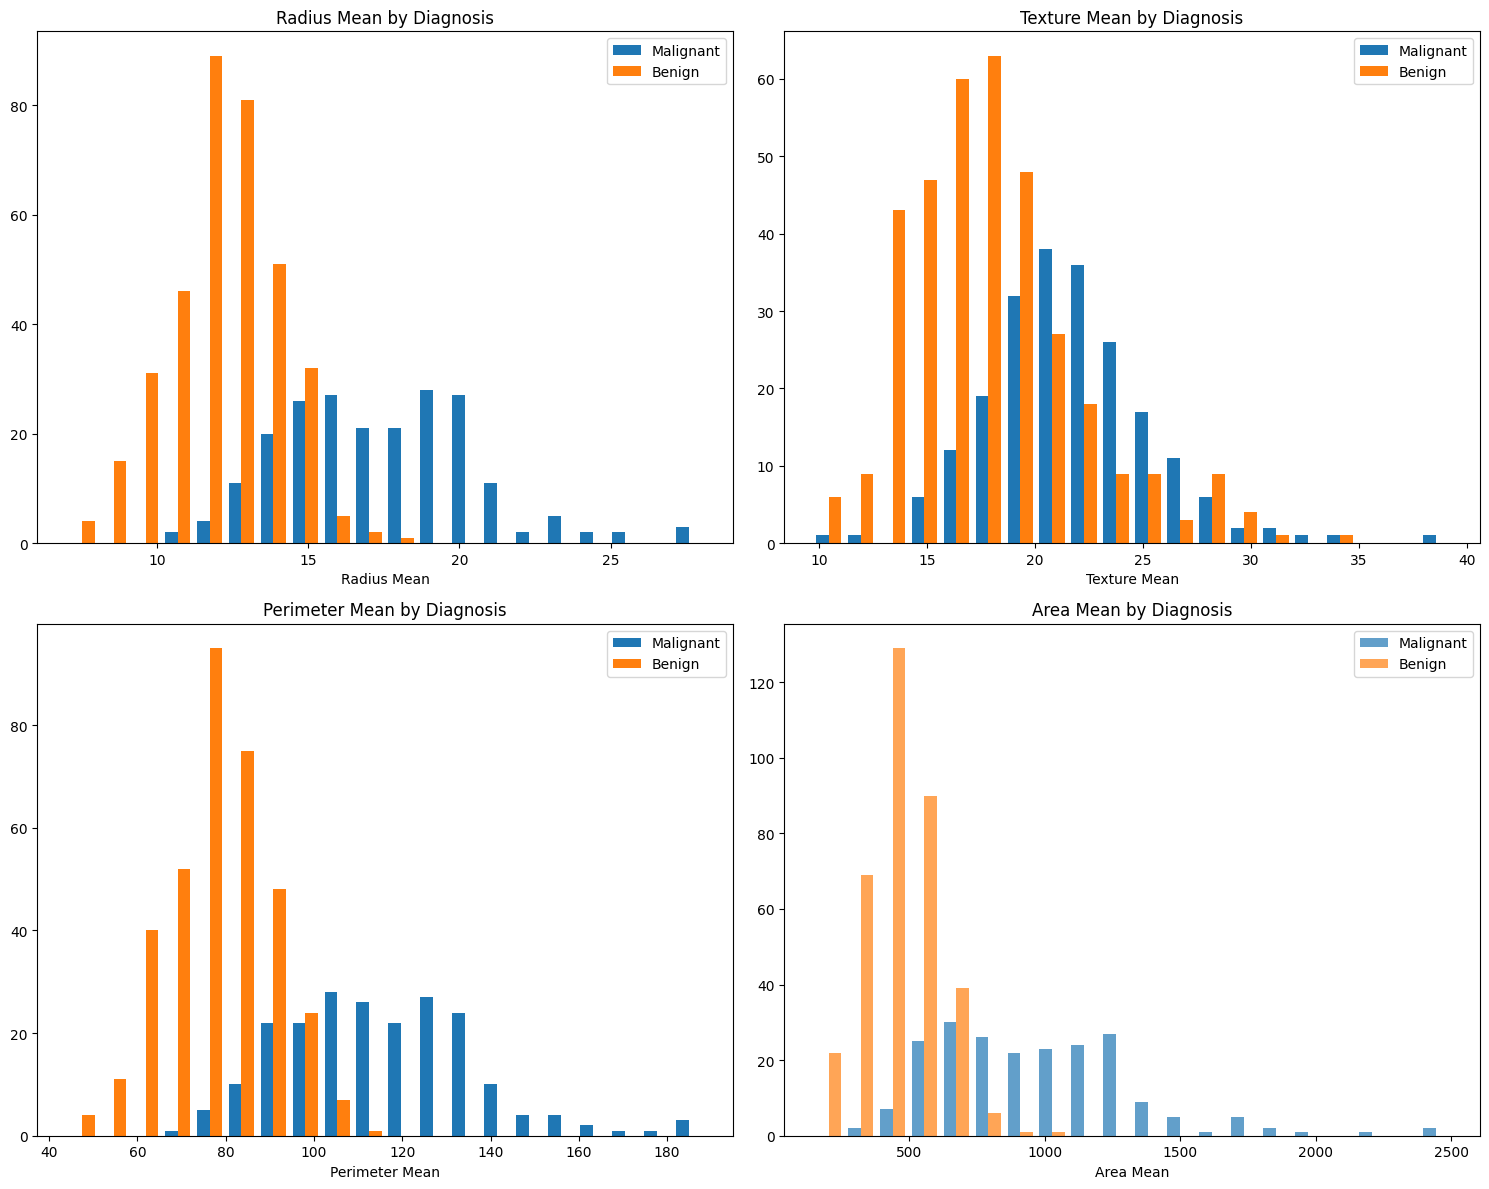

In [117]:
# Visualisasi distribusi beberapa fitur berdasarkan diagnosis
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# Radius mean by diagnosis
axes[0, 0].hist([cancer[cancer['diagnosis']=='M']['radius_mean'], 
                 cancer[cancer['diagnosis']=='B']['radius_mean']], 
                label=['Malignant', 'Benign'], bins=20)
axes[0, 0].set_title('Radius Mean by Diagnosis')
axes[0, 0].set_xlabel('Radius Mean')
axes[0, 0].legend()

# Texture mean by diagnosis
axes[0, 1].hist([cancer[cancer['diagnosis']=='M']['texture_mean'], 
                 cancer[cancer['diagnosis']=='B']['texture_mean']], 
                label=['Malignant', 'Benign'], bins=20)
axes[0, 1].set_title('Texture Mean by Diagnosis')
axes[0, 1].set_xlabel('Texture Mean')
axes[0, 1].legend()

# Perimeter mean by diagnosis
axes[1, 0].hist([cancer[cancer['diagnosis']=='M']['perimeter_mean'], 
                 cancer[cancer['diagnosis']=='B']['perimeter_mean']], 
                label=['Malignant', 'Benign'], bins=20)
axes[1, 0].set_title('Perimeter Mean by Diagnosis')
axes[1, 0].set_xlabel('Perimeter Mean')
axes[1, 0].legend()

# Area mean by diagnosis
axes[1, 1].hist([cancer[cancer['diagnosis']=='M']['area_mean'],
                 cancer[cancer['diagnosis']=='B']['area_mean']],
                label=['Malignant', 'Benign'], bins=20, alpha=0.7)
axes[1, 1].set_title('Area Mean by Diagnosis')
axes[1, 1].set_xlabel('Area Mean')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Encode diagnosis: M (Malignant) = 1, B (Benign) = 0
cancer['diagnosis'] = cancer['diagnosis'].map({'M': 1, 'B': 0})
print("Diagnosis encoding:")
print(cancer['diagnosis'].value_counts())

Diagnosis encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
X = cancer.drop(columns=['diagnosis'])
Y = cancer['diagnosis']

In [ ]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: object

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X.shape, X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

,priors,None
,var_smoothing,1e-09


In [113]:
train_pred_nb = nb_model.predict(X_train_scaled)
test_pred_nb = nb_model.predict(X_test_scaled)

print("Training Accuracy:", accuracy_score(Y_train, train_pred_nb))
print("Testing Accuracy:", accuracy_score(Y_test, test_pred_nb))

Training Accuracy: 0.9362637362637363
Testing Accuracy: 0.9649122807017544


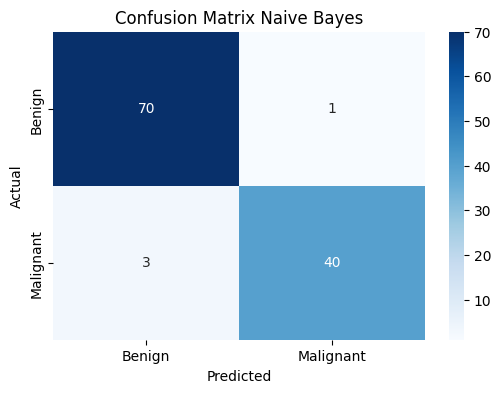

In [114]:
# Visualisasi Confusion Matrix (Naive Bayes)
plt.figure(figsize=(6,4))
cm_nb = confusion_matrix(Y_test, test_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
xticklabels=['Benign', 'Malignant'],
yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [115]:
print("Classification Report (Naive Bayes):")
print(classification_report(Y_test, test_pred_nb))

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [116]:
from sklearn.model_selection import cross_val_score
cv_nb = cross_val_score(nb_model, X, Y, cv = 5 , scoring='accuracy')
print("\nNaive Bayes Cross Validation Accuracy (5-Fold):")
print("Scores:", cv_nb)
print("Mean Accuracy:", cv_nb.mean())
print("Std Deviation:", cv_nb.std())


Naive Bayes Cross Validation Accuracy (5-Fold):
Scores: [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]
Mean Accuracy: 0.9385188635305075
Std Deviation: 0.014585994424363306
